# 🌊 파키스탄 2022년 홍수 시각화 (모자이크 버전)
## 여러 Sentinel-2 타일 병합

In [1]:
!pip install planetary-computer pystac-client rioxarray matplotlib numpy xarray cartopy rasterio pyproj --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl import gridliner
import planetary_computer
import pystac_client
import rasterio
from rasterio.merge import merge
from rasterio.warp import transform_bounds, reproject, Resampling, calculate_default_transform
from rasterio.windows import from_bounds
from rasterio import MemoryFile
from pyproj import CRS, Transformer
import warnings
warnings.filterwarnings('ignore')

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [3]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
print("✅ 연결 성공")

✅ 연결 성공


In [4]:
# 연구 지역
BBOX = {
    'min_lon': 67.5,
    'max_lon': 68.5,
    'min_lat': 26.5,
    'max_lat': 27.5
}
bbox_list = [BBOX['min_lon'], BBOX['min_lat'], BBOX['max_lon'], BBOX['max_lat']]
bounds = [BBOX['min_lon'], BBOX['max_lon'], BBOX['min_lat'], BBOX['max_lat']]

## 1. 타일 확인

In [5]:
# 해당 지역의 모든 타일 확인
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox_list,
    datetime="2022-09-01/2022-09-15",
    query={"eo:cloud_cover": {"lt": 20}},
    max_items=20
)
items = list(search.items())

print(f"총 {len(items)} scenes 검색됨")
print("\n타일 정보:")

# 타일별로 그룹화
tiles = {}
for item in items:
    tile_id = item.properties.get('s2:mgrs_tile', 'unknown')
    date = str(item.datetime.date())
    cloud = item.properties.get('eo:cloud_cover', 0)
    
    if tile_id not in tiles:
        tiles[tile_id] = []
    tiles[tile_id].append({'date': date, 'cloud': cloud, 'item': item})

for tile_id, info_list in tiles.items():
    print(f"\n  📍 타일 {tile_id}:")
    for info in info_list[:3]:  # 최대 3개만 표시
        print(f"     {info['date']} (cloud: {info['cloud']:.1f}%)")

총 20 scenes 검색됨

타일 정보:

  📍 타일 42RVR:
     2022-09-15 (cloud: 0.1%)
     2022-09-15 (cloud: 0.1%)
     2022-09-13 (cloud: 1.1%)

  📍 타일 42RUR:
     2022-09-15 (cloud: 0.1%)
     2022-09-15 (cloud: 0.1%)
     2022-09-13 (cloud: 4.1%)

  📍 타일 42RUQ:
     2022-09-15 (cloud: 18.0%)
     2022-09-15 (cloud: 18.0%)
     2022-09-13 (cloud: 6.3%)

  📍 타일 42RVQ:
     2022-09-13 (cloud: 2.4%)
     2022-09-10 (cloud: 0.0%)
     2022-09-08 (cloud: 2.4%)


## 2. 같은 날짜의 여러 타일 검색 함수

In [6]:
def search_tiles_by_date(catalog, bbox, target_date, date_tolerance_days=5, max_cloud=30):
    """
    특정 날짜 근처의 모든 타일 검색
    같은 날짜(또는 ±며칠)의 여러 타일을 찾아서 모자이크 가능하게
    """
    from datetime import datetime, timedelta
    
    # 날짜 파싱
    if isinstance(target_date, str):
        center_date = datetime.strptime(target_date, "%Y-%m-%d")
    else:
        center_date = target_date
    
    start = (center_date - timedelta(days=date_tolerance_days)).strftime("%Y-%m-%d")
    end = (center_date + timedelta(days=date_tolerance_days)).strftime("%Y-%m-%d")
    
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=f"{start}/{end}",
        query={"eo:cloud_cover": {"lt": max_cloud}},
        max_items=30
    )
    items = list(search.items())
    
    # 날짜별로 그룹화
    by_date = {}
    for item in items:
        date = str(item.datetime.date())
        if date not in by_date:
            by_date[date] = []
        by_date[date].append(item)
    
    # 가장 타일이 많은 날짜 선택 (또는 가장 구름 적은 날짜)
    best_date = None
    best_count = 0
    
    for date, date_items in by_date.items():
        if len(date_items) > best_count:
            best_count = len(date_items)
            best_date = date
    
    if best_date:
        return by_date[best_date], best_date
    return [], None

# 테스트
test_items, test_date = search_tiles_by_date(catalog, bbox_list, "2022-09-10")
print(f"\n{test_date}에 {len(test_items)}개 타일 발견")
for item in test_items:
    tile = item.properties.get('s2:mgrs_tile', 'unknown')
    print(f"  - {tile}: cloud {item.properties.get('eo:cloud_cover', 0):.1f}%")


2022-09-05에 8개 타일 발견
  - 42RVR: cloud 0.0%
  - 42RVR: cloud 0.0%
  - 42RVQ: cloud 0.0%
  - 42RVQ: cloud 0.0%
  - 42RUR: cloud 0.2%
  - 42RUR: cloud 0.2%
  - 42RUQ: cloud 2.8%
  - 42RUQ: cloud 2.8%


## 3. 여러 타일 모자이크 함수

In [7]:
def load_and_mosaic_tiles(items, band_name, bbox_wgs84, target_resolution=60):
    """
    여러 타일을 로드하고 모자이크
    
    Parameters:
    -----------
    items : list
        pystac Item 리스트
    band_name : str
        밴드 이름 (B02, B03, B04, B08)
    bbox_wgs84 : list
        [min_lon, min_lat, max_lon, max_lat]
    target_resolution : int
        출력 해상도 (미터)
    """
    datasets = []
    
    for item in items:
        if band_name not in item.assets:
            continue
            
        href = item.assets[band_name].href
        
        try:
            src = rasterio.open(href)
            datasets.append(src)
        except Exception as e:
            print(f"  Warning: {item.id} 로드 실패: {e}")
    
    if len(datasets) == 0:
        return None, None, None
    
    # 모자이크
    mosaic, mosaic_transform = merge(datasets)
    mosaic = mosaic[0]  # 첫 번째 밴드만
    
    # 원본 CRS
    src_crs = datasets[0].crs
    
    # 데이터셋 닫기
    for ds in datasets:
        ds.close()
    
    # WGS84 bbox를 src_crs로 변환
    bbox_transformed = transform_bounds(
        CRS.from_epsg(4326), src_crs,
        bbox_wgs84[0], bbox_wgs84[1], bbox_wgs84[2], bbox_wgs84[3]
    )
    
    # 목표 영역으로 crop하고 WGS84로 reproject
    dst_crs = CRS.from_epsg(4326)
    
    # 출력 크기 계산
    width = int((bbox_wgs84[2] - bbox_wgs84[0]) * 111000 / target_resolution)
    height = int((bbox_wgs84[3] - bbox_wgs84[1]) * 111000 / target_resolution)
    
    # 출력 transform
    dst_transform = rasterio.transform.from_bounds(
        bbox_wgs84[0], bbox_wgs84[1], bbox_wgs84[2], bbox_wgs84[3],
        width, height
    )
    
    # Reproject
    dst_array = np.zeros((height, width), dtype=mosaic.dtype)
    
    reproject(
        source=mosaic,
        destination=dst_array,
        src_transform=mosaic_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear
    )
    
    # 좌표 생성
    lons = np.linspace(bbox_wgs84[0], bbox_wgs84[2], width)
    lats = np.linspace(bbox_wgs84[3], bbox_wgs84[1], height)  # 북→남
    lon_2d, lat_2d = np.meshgrid(lons, lats)
    
    return dst_array, lon_2d, lat_2d

# 테스트
print("테스트 로드 중...")
test_green, lon, lat = load_and_mosaic_tiles(test_items, 'B03', bbox_list, target_resolution=100)

if test_green is not None:
    print(f"✅ Shape: {test_green.shape}")
    print(f"   Range: [{test_green.min()}, {test_green.max()}]")
    print(f"   Lon: [{lon.min():.2f}, {lon.max():.2f}]")
    print(f"   Lat: [{lat.min():.2f}, {lat.max():.2f}]")

테스트 로드 중...
✅ Shape: (1110, 1110)
   Range: [0, 10908]
   Lon: [67.50, 68.50]
   Lat: [26.50, 27.50]


## 4. 전체 밴드 로드 + NDWI

In [8]:
def load_sentinel2_mosaic(items, bbox_wgs84, resolution=60):
    """
    여러 타일을 모자이크하여 NDWI 계산
    """
    print(f"   {len(items)}개 타일 모자이크 중...")
    
    # 각 밴드 로드
    green, lon, lat = load_and_mosaic_tiles(items, 'B03', bbox_wgs84, resolution)
    nir, _, _ = load_and_mosaic_tiles(items, 'B08', bbox_wgs84, resolution)
    red, _, _ = load_and_mosaic_tiles(items, 'B04', bbox_wgs84, resolution)
    blue, _, _ = load_and_mosaic_tiles(items, 'B02', bbox_wgs84, resolution)
    
    if green is None:
        return None
    
    # float 변환
    green = green.astype(float)
    nir = nir.astype(float)
    red = red.astype(float)
    blue = blue.astype(float)
    
    # 0값 처리 (NoData)
    green[green == 0] = np.nan
    nir[nir == 0] = np.nan
    red[red == 0] = np.nan
    blue[blue == 0] = np.nan
    
    # NDWI 계산
    ndwi = (green - nir) / (green + nir + 1e-10)
    
    # RGB
    rgb = np.stack([red, green, blue], axis=-1)
    rgb = np.clip(rgb / 3000, 0, 1)
    rgb = np.nan_to_num(rgb, nan=1.0)  # NaN을 흰색으로
    
    return {
        'ndwi': ndwi,
        'rgb': rgb,
        'lon': lon,
        'lat': lat,
        'shape': ndwi.shape
    }

## 5. 전체 시계열 로드

In [9]:
# 분석할 시점 (목표 날짜)
TARGET_DATES = [
    "2022-06-01",   # 홍수 전
    "2022-08-01",   # 초기
    "2022-09-01",   # 피크
    "2022-11-01",   # 홍수 후
]
PERIOD_LABELS = ['Pre-flood (Jun)', 'Early (Aug)', 'Peak (Sep)', 'Post-flood (Nov)']

# 각 시점별 로드
all_data = {}

print("📥 전체 시계열 로드:")
print("="*60)

for target_date, label in zip(TARGET_DATES, PERIOD_LABELS):
    print(f"\n{label} ({target_date})...")
    
    # 해당 날짜 근처의 타일들 검색
    items, actual_date = search_tiles_by_date(
        catalog, bbox_list, target_date, 
        date_tolerance_days=15, max_cloud=40
    )
    
    if len(items) == 0:
        print(f"   ❌ 데이터 없음")
        continue
    
    print(f"   날짜: {actual_date}, 타일: {len(items)}개")
    
    # 로드 및 모자이크
    try:
        result = load_sentinel2_mosaic(items, bbox_list, resolution=60)
        
        if result is not None and result['shape'][0] > 1:
            all_data[label] = result
            print(f"   ✅ Shape: {result['shape']}")
            print(f"   NDWI: [{np.nanmin(result['ndwi']):.2f}, {np.nanmax(result['ndwi']):.2f}]")
        else:
            print(f"   ❌ 로드 실패")
    except Exception as e:
        print(f"   ❌ Error: {e}")

print(f"\n" + "="*60)
print(f"✅ 총 {len(all_data)}개 시점 로드 완료")

📥 전체 시계열 로드:

Pre-flood (Jun) (2022-06-01)...
   날짜: 2022-06-15, 타일: 8개
   8개 타일 모자이크 중...
   ✅ Shape: (1850, 1850)
   NDWI: [-0.70, 0.82]

Early (Aug) (2022-08-01)...
   날짜: 2022-08-04, 타일: 4개
   4개 타일 모자이크 중...
   ✅ Shape: (1850, 1850)
   NDWI: [-0.90, 0.91]

Peak (Sep) (2022-09-01)...
   날짜: 2022-09-15, 타일: 8개
   8개 타일 모자이크 중...
   ✅ Shape: (1850, 1850)
   NDWI: [-0.87, 0.88]

Post-flood (Nov) (2022-11-01)...
   날짜: 2022-11-04, 타일: 7개
   7개 타일 모자이크 중...
   ✅ Shape: (1850, 1850)
   NDWI: [-0.71, 0.90]

✅ 총 4개 시점 로드 완료


## 6. 수체 탐지

In [10]:
WATER_THRESHOLD = 0.0

water_masks = {}
print("📊 수체 탐지:")
print("-"*40)

for label, data in all_data.items():
    mask = data['ndwi'] > WATER_THRESHOLD
    water_masks[label] = mask
    valid_pixels = np.sum(~np.isnan(data['ndwi']))
    water_pixels = np.nansum(mask)
    pct = water_pixels / valid_pixels * 100 if valid_pixels > 0 else 0
    print(f"{label:20s}: {pct:5.1f}% ({water_pixels:,} pixels)")

📊 수체 탐지:
----------------------------------------
Pre-flood (Jun)     :   0.3% (1,980 pixels)
Early (Aug)         :  11.8% (191,172 pixels)
Peak (Sep)          :  29.3% (989,064 pixels)
Post-flood (Nov)    :  17.4% (454,993 pixels)


## 7. 각 시점 확인

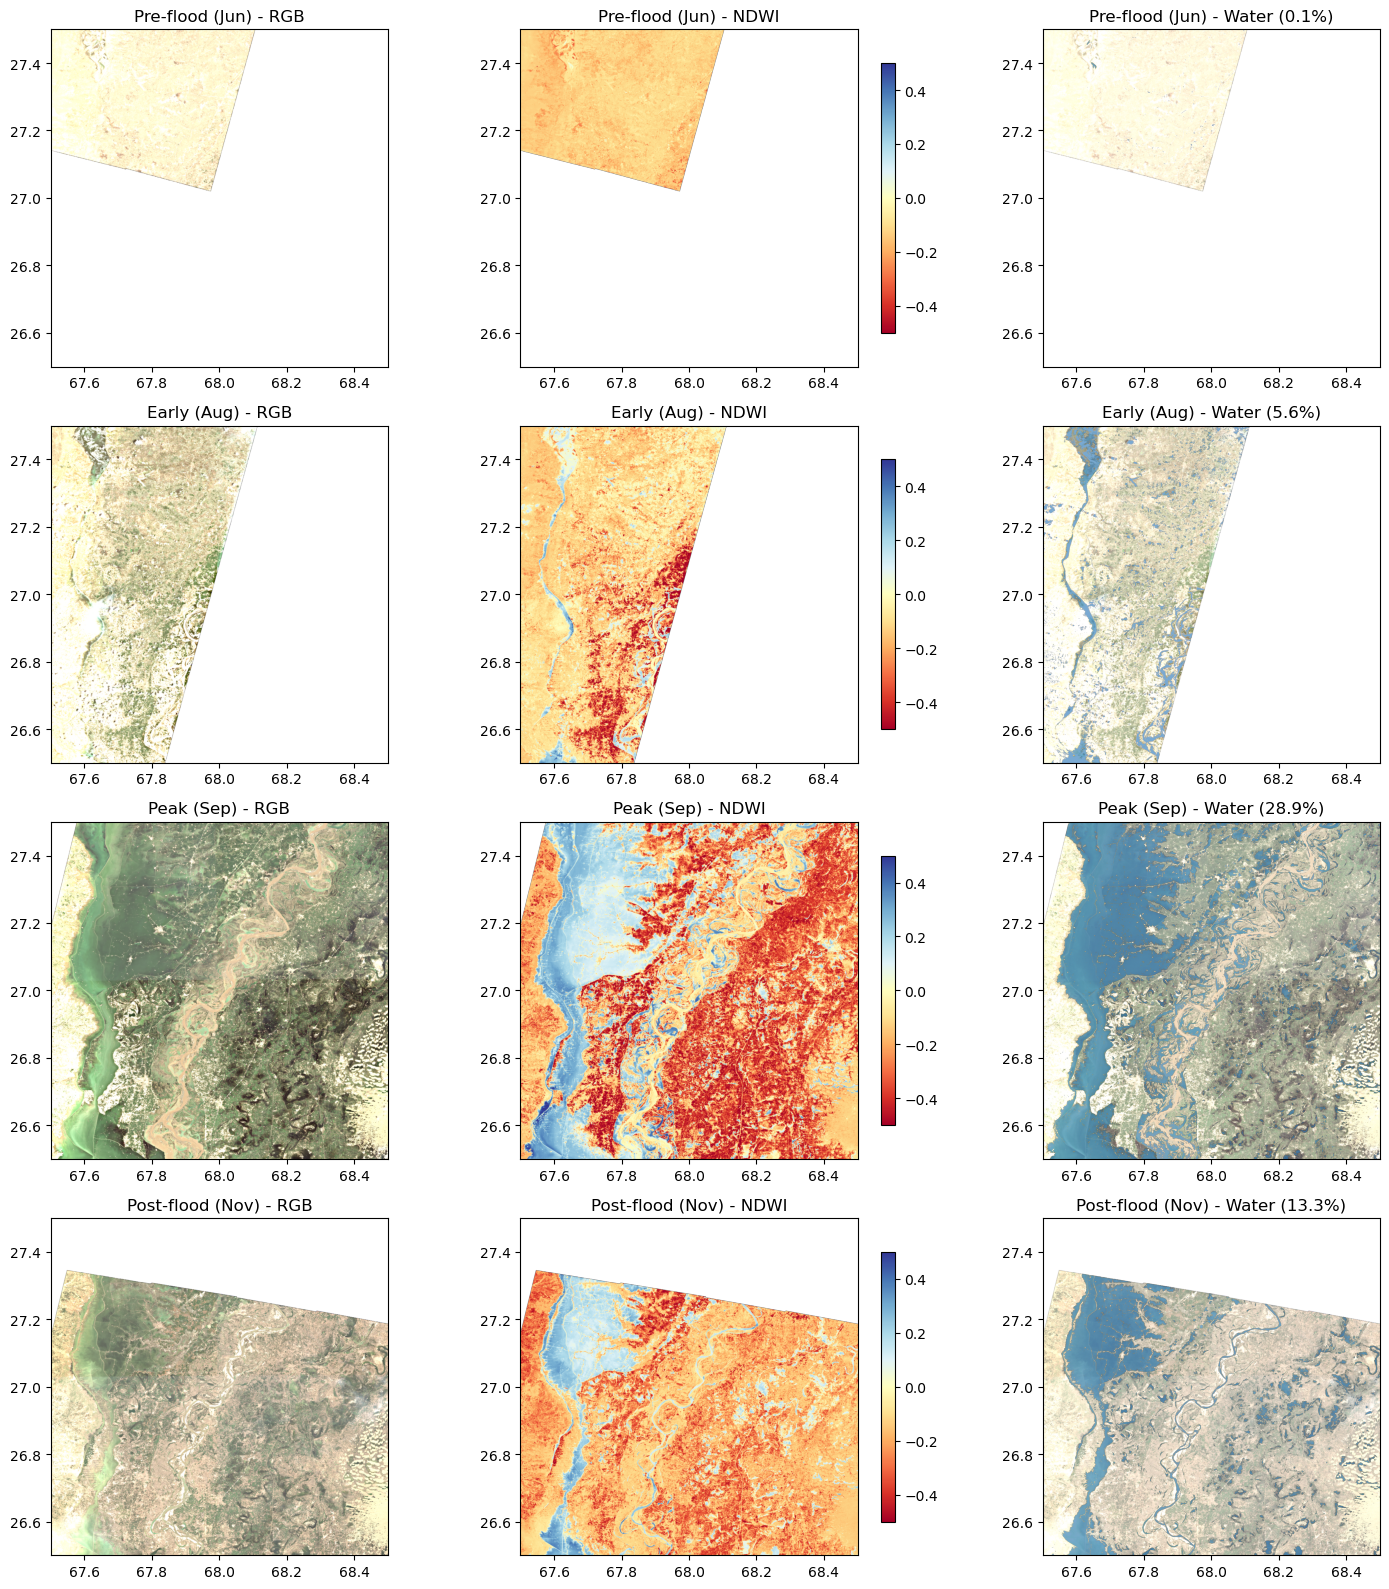

In [11]:
n = len(all_data)
if n > 0:
    fig, axes = plt.subplots(n, 3, figsize=(15, 4*n))
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for i, (label, data) in enumerate(all_data.items()):
        # RGB
        axes[i, 0].imshow(data['rgb'], origin='upper',
                          extent=[data['lon'].min(), data['lon'].max(),
                                  data['lat'].min(), data['lat'].max()])
        axes[i, 0].set_title(f'{label} - RGB')
        
        # NDWI
        im = axes[i, 1].imshow(data['ndwi'], origin='upper', cmap='RdYlBu',
                               vmin=-0.5, vmax=0.5,
                               extent=[data['lon'].min(), data['lon'].max(),
                                       data['lat'].min(), data['lat'].max()])
        axes[i, 1].set_title(f'{label} - NDWI')
        plt.colorbar(im, ax=axes[i, 1], shrink=0.8)
        
        # 수체 마스크
        axes[i, 2].imshow(data['rgb'], origin='upper', alpha=0.7,
                          extent=[data['lon'].min(), data['lon'].max(),
                                  data['lat'].min(), data['lat'].max()])
        water_overlay = np.ma.masked_where(~water_masks[label],
                                            np.ones_like(water_masks[label]))
        axes[i, 2].imshow(water_overlay, origin='upper',
                          cmap=mcolors.ListedColormap(['#2171b5']), alpha=0.6,
                          extent=[data['lon'].min(), data['lon'].max(),
                                  data['lat'].min(), data['lat'].max()])
        pct = np.nanmean(water_masks[label]) * 100
        axes[i, 2].set_title(f'{label} - Water ({pct:.1f}%)')
    
    plt.tight_layout()
    plt.savefig('flood_stages_check.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. 🎨 메인 시각화: 시간별 침수 그라데이션

🎨 시각화 생성 중...
✅ 저장: pakistan_flood_mosaic.png


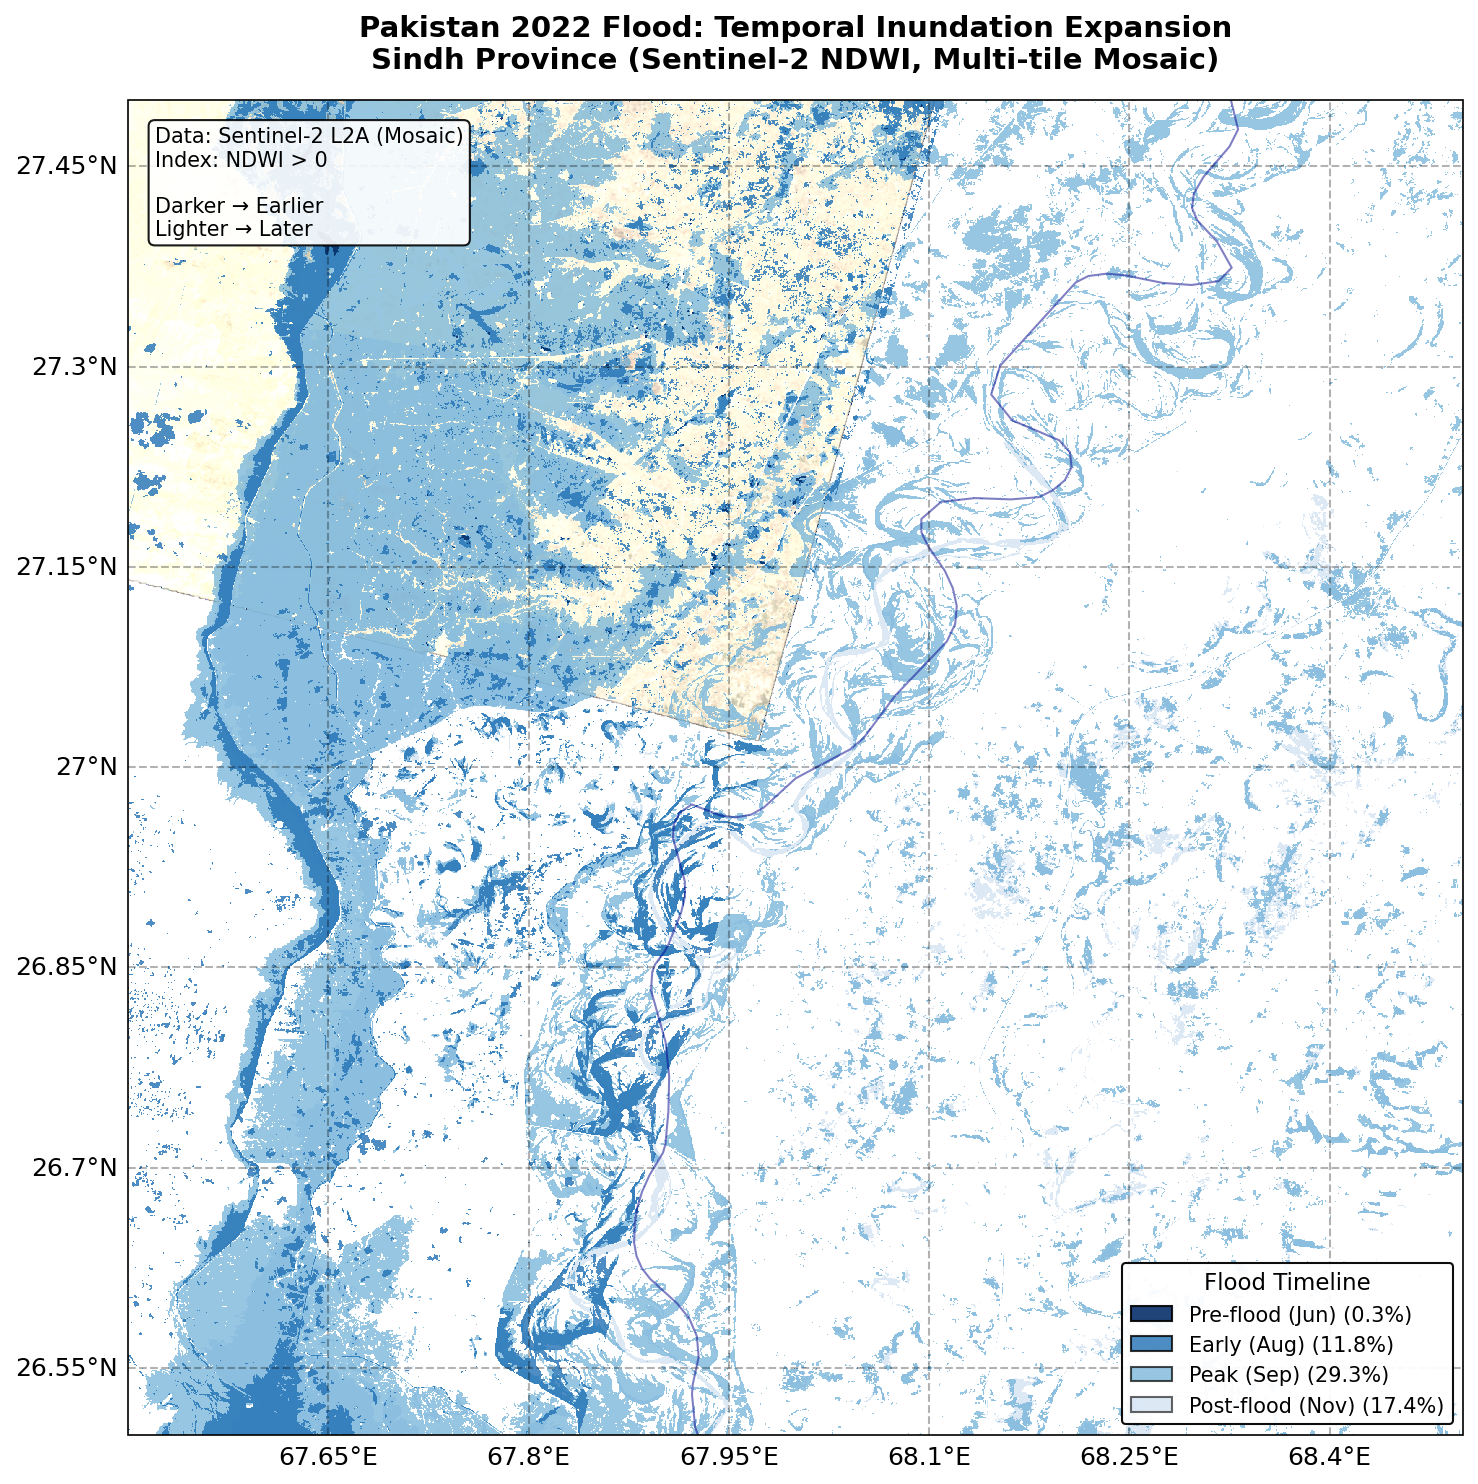

In [12]:
def plot_temporal_flood_gradient(all_data, water_masks, bbox, save_path=None):
    """
    시간별 침수 확장을 단일 패널에 그라데이션으로 시각화
    """
    fig, ax = plt.subplots(figsize=(12, 10),
                           subplot_kw={'projection': ccrs.PlateCarree()},
                           dpi=150)
    
    extent = [bbox['min_lon'], bbox['max_lon'], bbox['min_lat'], bbox['max_lat']]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # 첫 데이터
    first_key = list(all_data.keys())[0]
    lon = all_data[first_key]['lon']
    lat = all_data[first_key]['lat']
    
    # 배경 RGB
    rgb = all_data[first_key]['rgb']
    ax.imshow(rgb, extent=[lon.min(), lon.max(), lat.min(), lat.max()],
              transform=ccrs.PlateCarree(), origin='upper', alpha=0.6)
    
    # 색상 팔레트
    flood_colors = ['#08306b', '#2171b5', '#6baed6', '#c6dbef']
    alphas = [0.9, 0.8, 0.7, 0.6]
    
    # 역순 레이어링
    mask_keys = list(water_masks.keys())
    legend_elements = []
    
    for i in range(len(mask_keys)-1, -1, -1):
        key = mask_keys[i]
        mask = water_masks[key].astype(float)
        mask[~water_masks[key]] = np.nan
        
        color_idx = min(i, len(flood_colors)-1)
        cmap_single = mcolors.ListedColormap([flood_colors[color_idx]])
        
        ax.pcolormesh(lon, lat, mask,
                      transform=ccrs.PlateCarree(),
                      cmap=cmap_single,
                      alpha=alphas[color_idx],
                      shading='auto')
    
    # 지도 피처
    ax.coastlines(linewidth=1, color='black')
    ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.8)
    ax.add_feature(cfeature.RIVERS, edgecolor='darkblue', alpha=0.5)
    
    # 그리드라인
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='black', alpha=0.3, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = gridliner.LONGITUDE_FORMATTER
    gl.yformatter = gridliner.LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}
    
    # 범례
    for i, key in enumerate(mask_keys):
        color_idx = min(i, len(flood_colors)-1)
        valid = np.sum(~np.isnan(all_data[key]['ndwi']))
        pct = np.nansum(water_masks[key]) / valid * 100 if valid > 0 else 0
        legend_elements.append(
            Patch(facecolor=flood_colors[color_idx], edgecolor='black',
                  alpha=alphas[color_idx], label=f"{key} ({pct:.1f}%)")
        )
    
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
              framealpha=0.95, edgecolor='black',
              title='Flood Timeline', title_fontsize=11)
    
    ax.set_title('Pakistan 2022 Flood: Temporal Inundation Expansion\n'
                 'Sindh Province (Sentinel-2 NDWI, Multi-tile Mosaic)',
                 fontsize=14, fontweight='bold', pad=15)
    
    ax.text(0.02, 0.98,
            'Data: Sentinel-2 L2A (Mosaic)\n'
            'Index: NDWI > 0\n'
            '\n'
            'Darker → Earlier\n'
            'Lighter → Later',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ 저장: {save_path}")
    
    plt.show()
    return fig, ax

# 실행
if len(all_data) >= 2:
    print("🎨 시각화 생성 중...")
    fig, ax = plot_temporal_flood_gradient(
        all_data, water_masks, BBOX,
        save_path='pakistan_flood_mosaic.png'
    )

## 9. 새로 침수된 영역만

✅ 저장: pakistan_flood_sequential.png


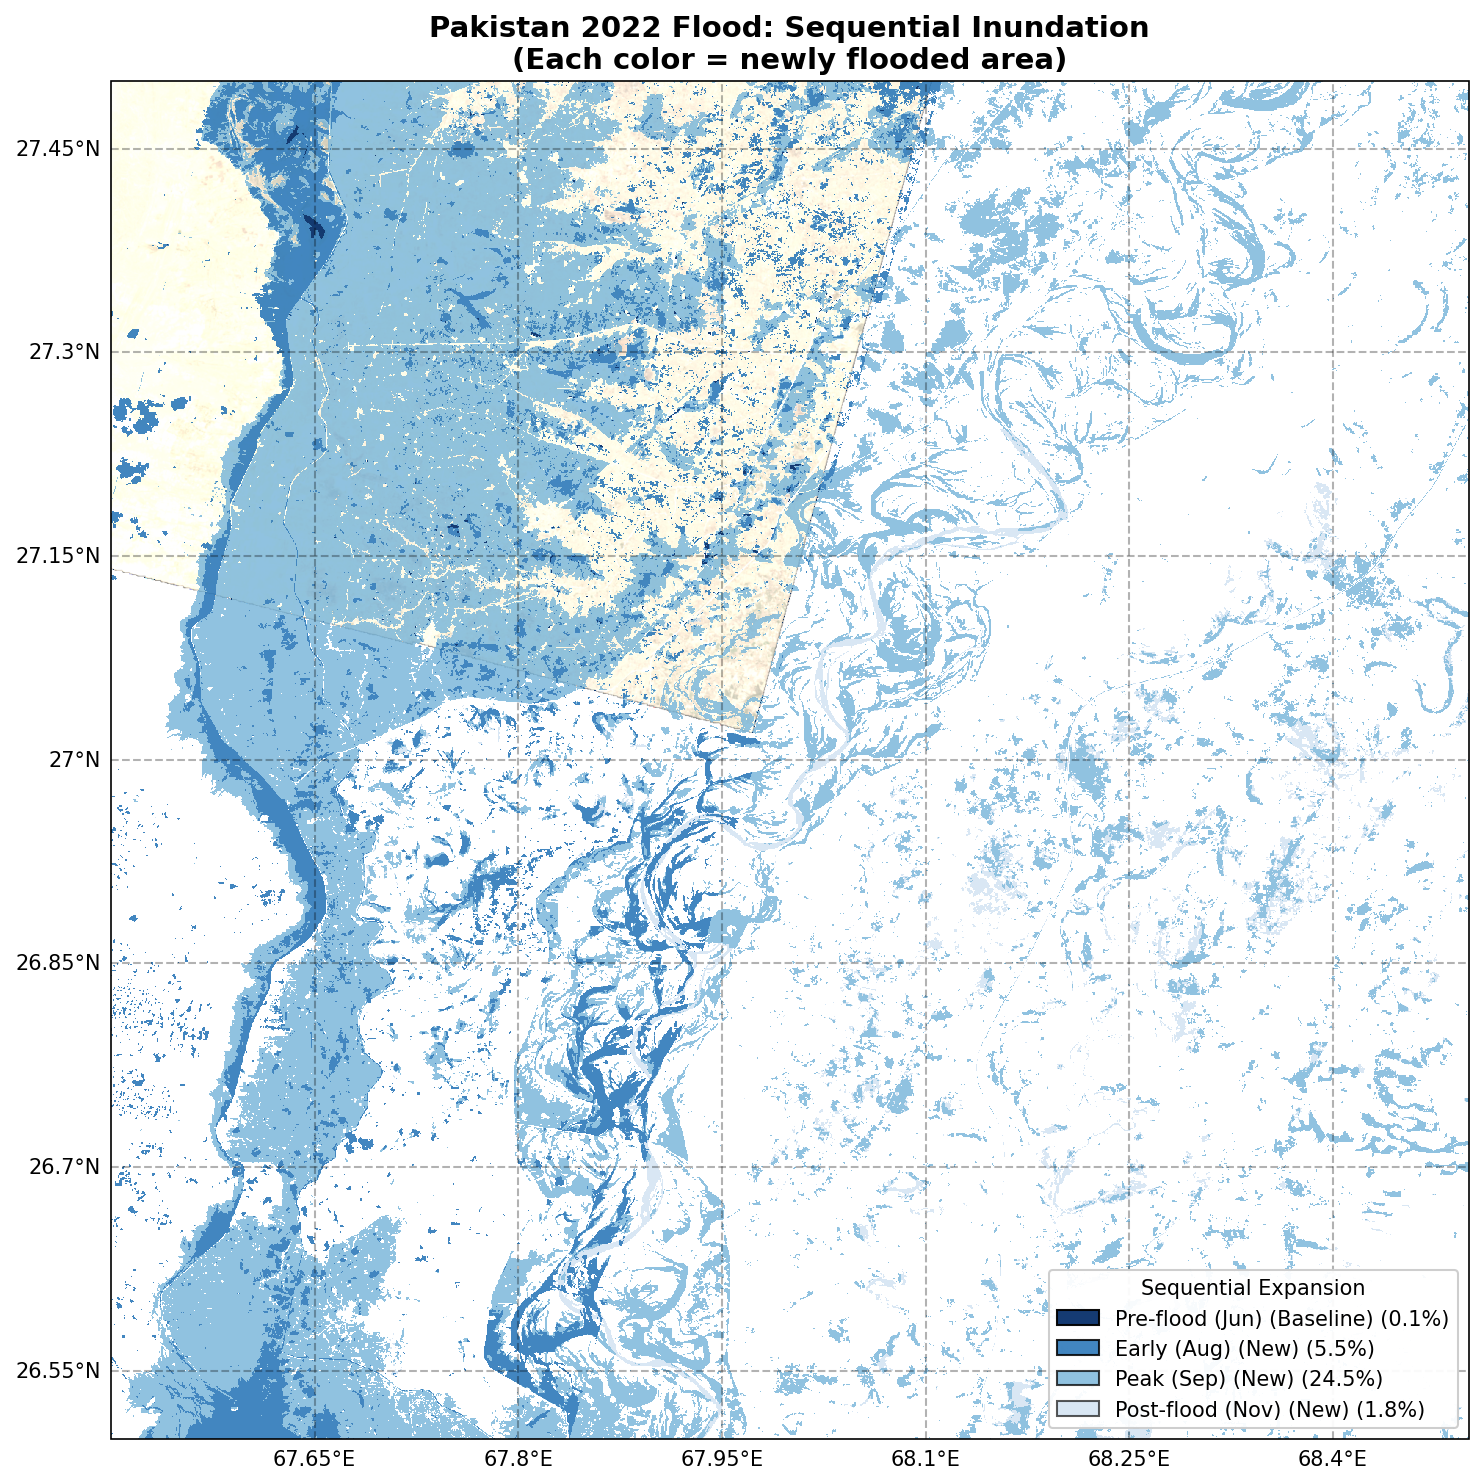

In [13]:
def plot_sequential_flood(all_data, water_masks, bbox, save_path=None):
    fig, ax = plt.subplots(figsize=(12, 10),
                           subplot_kw={'projection': ccrs.PlateCarree()},
                           dpi=150)
    
    extent = [bbox['min_lon'], bbox['max_lon'], bbox['min_lat'], bbox['max_lat']]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    first_key = list(all_data.keys())[0]
    lon = all_data[first_key]['lon']
    lat = all_data[first_key]['lat']
    
    rgb = all_data[first_key]['rgb']
    ax.imshow(rgb, extent=[lon.min(), lon.max(), lat.min(), lat.max()],
              transform=ccrs.PlateCarree(), origin='upper', alpha=0.5)
    
    flood_colors = ['#08306b', '#2171b5', '#6baed6', '#c6dbef']
    alphas = [0.95, 0.85, 0.75, 0.65]
    
    mask_keys = list(water_masks.keys())
    legend_elements = []
    cumulative = np.zeros_like(water_masks[mask_keys[0]], dtype=bool)
    
    for i, key in enumerate(mask_keys):
        current = water_masks[key]
        
        if i == 0:
            new_area = current
            label_suffix = "(Baseline)"
        else:
            new_area = current & ~cumulative
            label_suffix = "(New)"
        
        cumulative = cumulative | current
        
        mask_float = new_area.astype(float)
        mask_float[~new_area] = np.nan
        
        color_idx = min(i, len(flood_colors)-1)
        cmap_single = mcolors.ListedColormap([flood_colors[color_idx]])
        
        ax.pcolormesh(lon, lat, mask_float,
                      transform=ccrs.PlateCarree(),
                      cmap=cmap_single,
                      alpha=alphas[color_idx],
                      shading='auto')
        
        pct = np.sum(new_area) / new_area.size * 100
        legend_elements.append(
            Patch(facecolor=flood_colors[color_idx], edgecolor='black',
                  alpha=alphas[color_idx],
                  label=f"{key} {label_suffix} ({pct:.1f}%)")
        )
    
    ax.coastlines(linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='black', alpha=0.3, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = gridliner.LONGITUDE_FORMATTER
    gl.yformatter = gridliner.LATITUDE_FORMATTER
    
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
              framealpha=0.95, title='Sequential Expansion')
    
    ax.set_title('Pakistan 2022 Flood: Sequential Inundation\n'
                 '(Each color = newly flooded area)',
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ 저장: {save_path}")
    
    plt.show()
    return fig, ax

if len(all_data) >= 2:
    fig2, ax2 = plot_sequential_flood(
        all_data, water_masks, BBOX,
        save_path='pakistan_flood_sequential.png'
    )

## 10. 통계

In [14]:
if len(water_masks) >= 2:
    # 60m resolution
    pixel_area_km2 = (60 * 60) / 1e6
    
    print("="*60)
    print("📊 침수 면적 통계")
    print("="*60)
    
    first_area = None
    for label, mask in water_masks.items():
        area = np.nansum(mask) * pixel_area_km2
        
        if first_area is None:
            first_area = area
            print(f"{label:25s}: {area:8.1f} km² (baseline)")
        else:
            change = area - first_area
            pct = (change / first_area) * 100 if first_area > 0 else 0
            print(f"{label:25s}: {area:8.1f} km² ({change:+.1f}, {pct:+.0f}%)")
    
    print("="*60)

📊 침수 면적 통계
Pre-flood (Jun)          :      7.1 km² (baseline)
Early (Aug)              :    688.2 km² (+681.1, +9555%)
Peak (Sep)               :   3560.6 km² (+3553.5, +49853%)
Post-flood (Nov)         :   1638.0 km² (+1630.8, +22879%)
